## 10b. Candidate Exogenous Feature Screening For Trimmed-Mean Elastic Net

This repeats the same external-macro screening workflow with `trimmed_mean_cpi_yoy` as the target. It excludes CPI-family diagnostic columns as predictors so the trimmed-mean model receives an independent candidate exogenous pool rather than a second headline-CPI comparison.

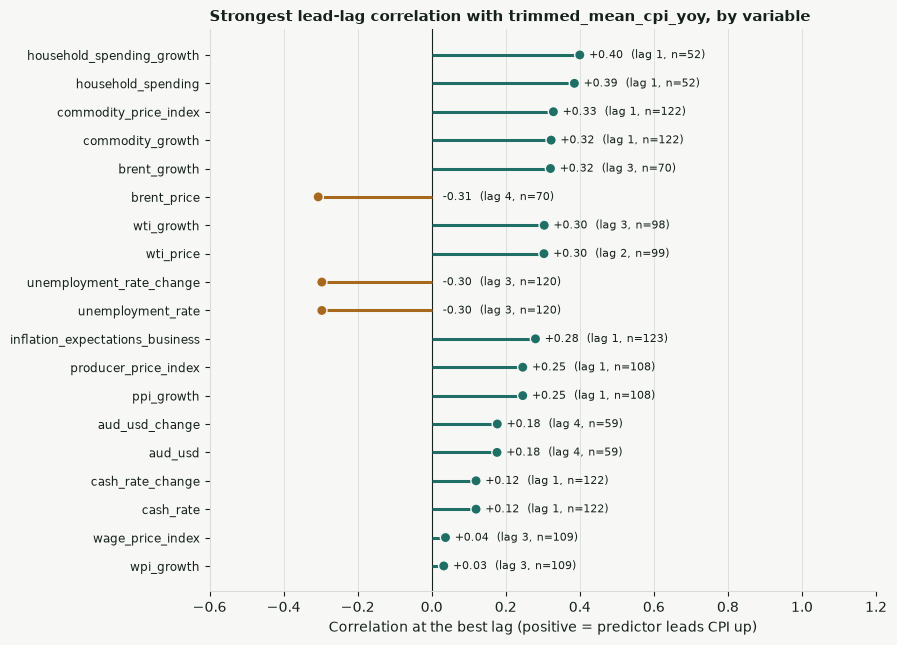

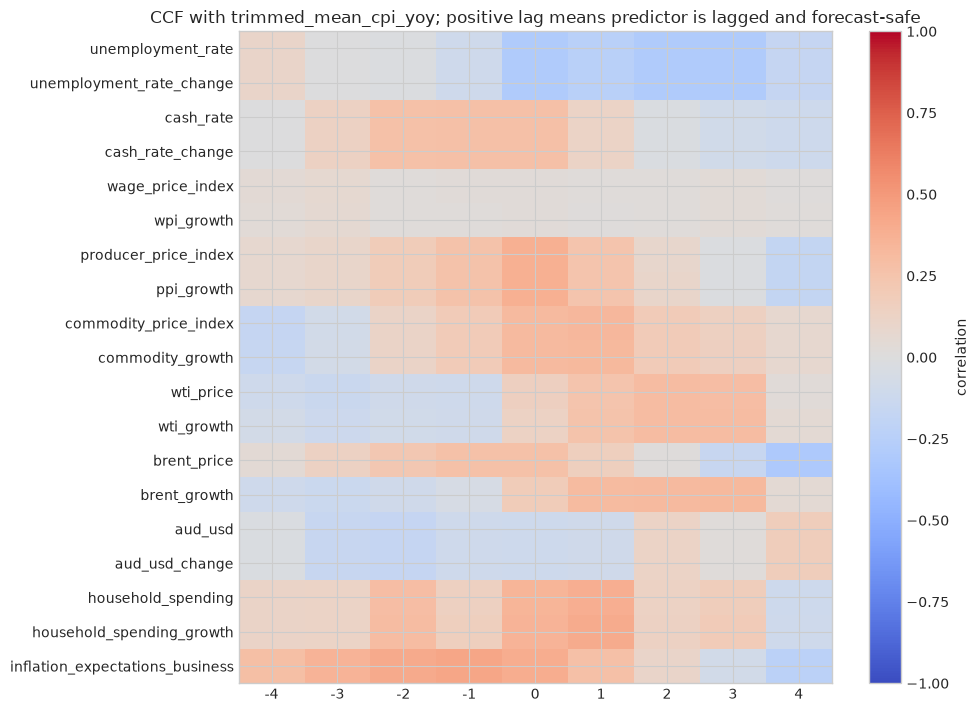

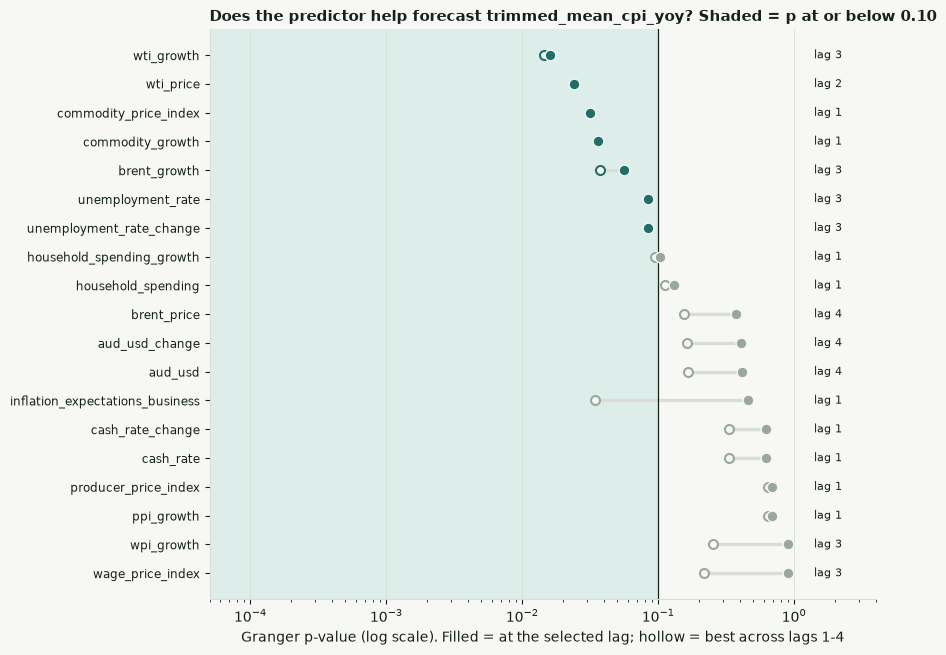

Complete rows for the correlation and VIF step: 62 (2010Q3 to 2025Q4)


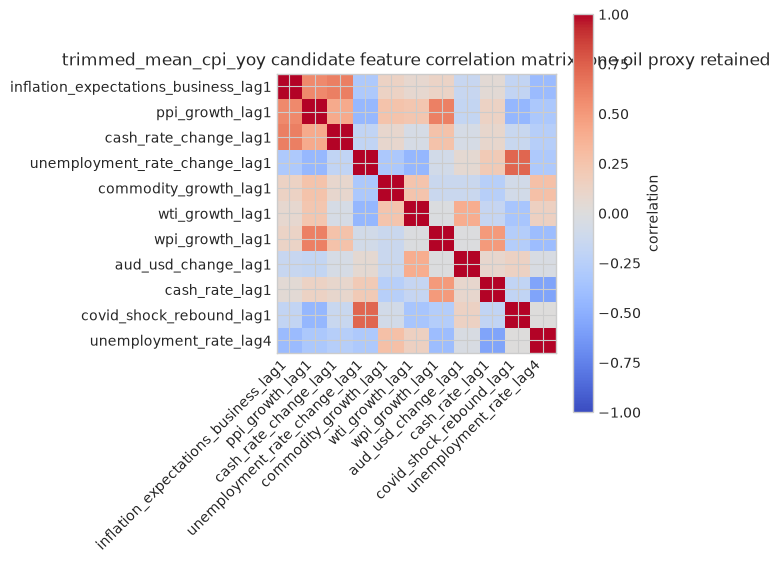

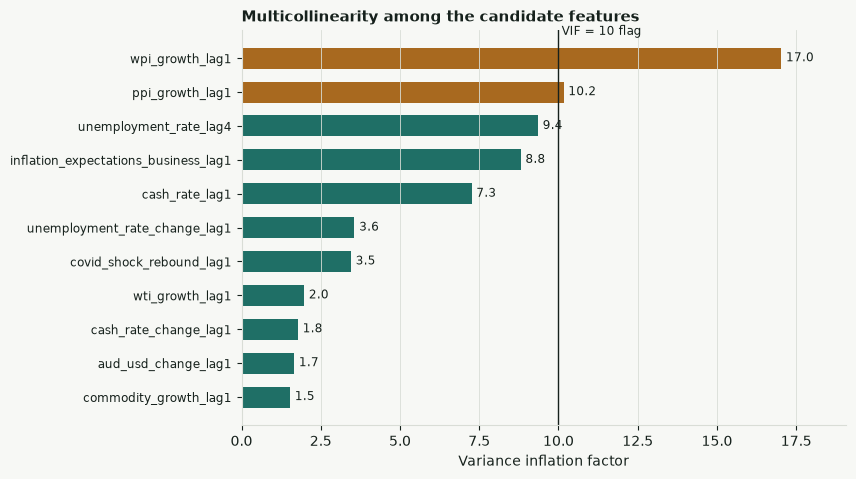

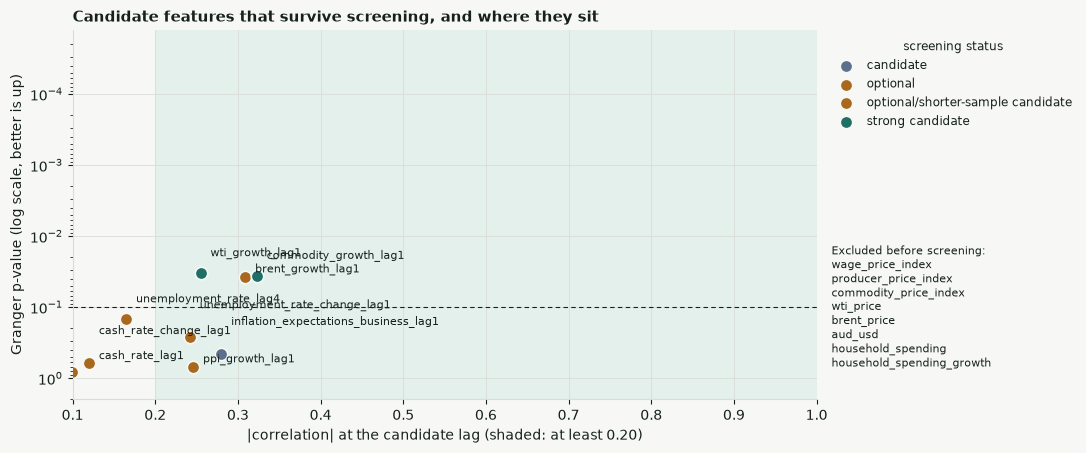

Elastic Net candidate pool from trimmed-mean CPI EDA screening: inflation_expectations_business_lag1, brent_growth_lag1, unemployment_rate_change_lag1, ppi_growth_lag1, wti_growth_lag1, commodity_growth_lag1

These are not final feature-selection results. The modelling stage should compare a small set of nested Elastic Net feature specifications with walk-forward RMSE/MAE against seasonal-naive and SARIMA baselines, not exhaustive subset search on this small sample.

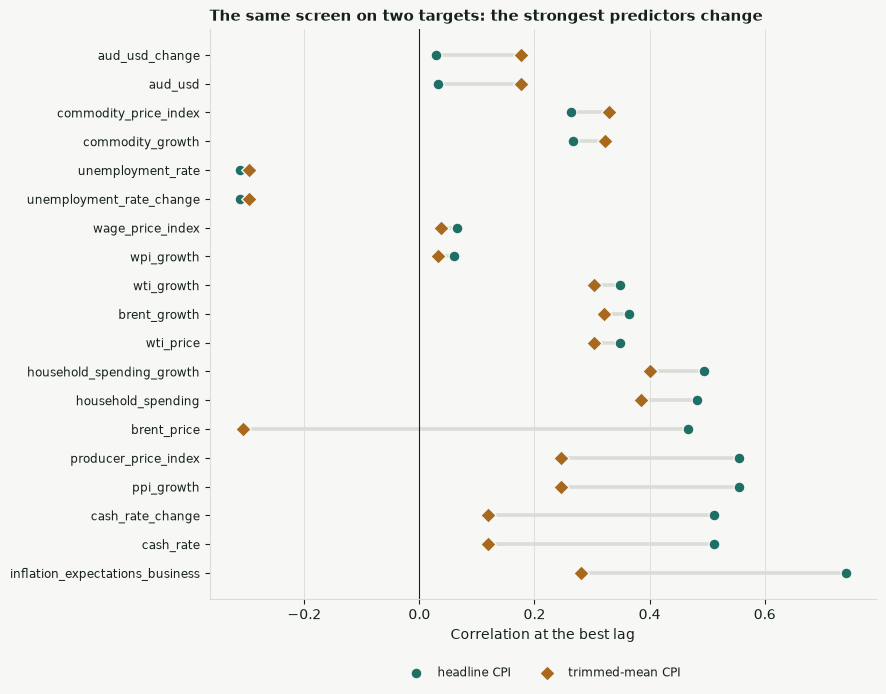

In [13]:
TRIMMED_MEAN_TARGET = 'trimmed_mean_cpi_yoy'
trimmed_correlation_base_cols = correlation_columns_for_target(TRIMMED_MEAN_TARGET, include_cpi_diagnostics=False)
trimmed_ccf, trimmed_best_predictive_ccf, trimmed_target_stationary = compute_lead_lag_correlation(
    TRIMMED_MEAN_TARGET,
    trimmed_correlation_base_cols,
)
display_lead_lag_correlation(TRIMMED_MEAN_TARGET, trimmed_correlation_base_cols, trimmed_ccf, trimmed_best_predictive_ccf)

trimmed_granger, trimmed_granger_lag_results, trimmed_best_lag_lookup = compute_granger_screens(
    TRIMMED_MEAN_TARGET,
    trimmed_correlation_base_cols,
    trimmed_target_stationary,
    trimmed_best_predictive_ccf,
)
display_granger_screens(trimmed_granger, trimmed_granger_lag_results)

trimmed_candidate_artifacts = build_target_candidate_artifacts(
    TRIMMED_MEAN_TARGET,
    trimmed_best_predictive_ccf,
    trimmed_ccf,
    trimmed_granger_lag_results,
    show_diagnostics=True,
)
trimmed_shortlist_artifacts = build_target_shortlist(
    TRIMMED_MEAN_TARGET,
    trimmed_candidate_artifacts,
    trimmed_best_predictive_ccf,
    trimmed_granger,
    'Elastic Net candidate pool from trimmed-mean CPI EDA screening',
    show_result=True,
)
trimmed_shortlist = trimmed_shortlist_artifacts['shortlist']
trimmed_chosen_feature_by_base = trimmed_shortlist_artifacts['chosen_feature_by_base']

def target_external_screen_summary(target: str, best_ccf_frame: pd.DataFrame, granger_frame: pd.DataFrame, shortlist_frame: pd.DataFrame) -> pd.DataFrame:
    best = best_ccf_frame.loc[best_ccf_frame['variable'].isin(EXTERNAL_BASE_COLS), ['variable', 'lag_quarters', 'correlation', 'n_obs']].copy()
    best = best.rename(columns={
        'lag_quarters': f'{target}_best_ccf_lag',
        'correlation': f'{target}_best_ccf_corr',
        'n_obs': f'{target}_ccf_n_obs',
    })
    granger_summary = granger_frame.loc[granger_frame['variable'].isin(EXTERNAL_BASE_COLS), ['variable', 'granger_p_value', 'min_granger_p_value']].copy()
    granger_summary = granger_summary.rename(columns={
        'granger_p_value': f'{target}_selected_granger_p',
        'min_granger_p_value': f'{target}_min_granger_p',
    })
    candidate_summary = shortlist_frame[['variable', 'candidate_feature', 'candidate_corr', 'candidate_granger_p_value', 'screening_status']].copy()
    candidate_summary = candidate_summary.rename(columns={
        'candidate_feature': f'{target}_candidate_feature',
        'candidate_corr': f'{target}_candidate_corr',
        'candidate_granger_p_value': f'{target}_candidate_granger_p',
        'screening_status': f'{target}_screening_status',
    })
    return best.merge(granger_summary, on='variable', how='outer').merge(candidate_summary, on='variable', how='outer')


headline_external_summary = target_external_screen_summary(TARGET, best_predictive_ccf, granger, shortlist)
trimmed_external_summary = target_external_screen_summary(TRIMMED_MEAN_TARGET, trimmed_best_predictive_ccf, trimmed_granger, trimmed_shortlist)
headline_vs_trimmed_screen = headline_external_summary.merge(trimmed_external_summary, on='variable', how='outer')
headline_vs_trimmed_screen['abs_best_ccf_corr_diff'] = (
    headline_vs_trimmed_screen[f'{TRIMMED_MEAN_TARGET}_best_ccf_corr'].abs()
    - headline_vs_trimmed_screen[f'{TARGET}_best_ccf_corr'].abs()
)
headline_vs_trimmed_screen['selected_granger_signal_changed'] = (
    headline_vs_trimmed_screen[f'{TARGET}_selected_granger_p'].le(SIGNAL_P_THRESHOLD)
    != headline_vs_trimmed_screen[f'{TRIMMED_MEAN_TARGET}_selected_granger_p'].le(SIGNAL_P_THRESHOLD)
)
with plt.rc_context(BOOK_STYLE):
    h = headline_vs_trimmed_screen.dropna(subset=["cpi_yoy_best_ccf_corr", "trimmed_mean_cpi_yoy_best_ccf_corr"]).copy()
    h = h.sort_values("abs_best_ccf_corr_diff").reset_index(drop=True)
    fig, ax = plt.subplots(figsize=(8.6, 0.3 * len(h) + 1.7))
    ax.axvline(0, color=INK, linewidth=0.8)
    for y, r in h.iterrows():
        ax.plot([r["cpi_yoy_best_ccf_corr"], r["trimmed_mean_cpi_yoy_best_ccf_corr"]], [y, y], color=GRID, linewidth=2.6, zorder=1)
    ax.scatter(h["cpi_yoy_best_ccf_corr"], h.index, s=62, color=ACCENT, edgecolor=PAPER, linewidth=1.0, zorder=3,
               label="headline CPI")
    ax.scatter(h["trimmed_mean_cpi_yoy_best_ccf_corr"], h.index, s=62, marker="D", color=HIGHLIGHT, edgecolor=PAPER,
               linewidth=1.0, zorder=3, label="trimmed-mean CPI")
    ax.set_yticks(h.index, h["variable"], fontsize=8.4)
    ax.set_xlabel("Correlation at the best lag")
    ax.set_title("The same screen on two targets: the strongest predictors change",
                 loc="left", fontsize=10.5, fontweight="bold")
    ax.legend(frameon=False, fontsize=8.5, loc="upper center", bbox_to_anchor=(0.5, -0.1), ncol=2)
    ax.grid(axis="y", visible=False)
    plt.show()

**Interpretation.** Re-running the same screen with `trimmed_mean_cpi_yoy` as the target
surfaces a *materially different* candidate mix, not a smaller version of the headline one:
the demand/policy/expectations signals that dominate headline screening weaken sharply here
(inflation expectations drops from corr=0.74 to 0.28; the cash rate drops from 0.51 to 0.12),
while commodity and oil-price features move to the front (`commodity_growth_lag1` corr=0.32,
`wti_growth_lag1` corr=0.30). That's why the trimmed-mean Elastic Net's feature block in §4.2 leads with commodity and
oil-price terms — trimmed-mean inflation, which discards the volatile top/bottom 15% of
price changes, is genuinely driven by a different set of macro forces. It still carries the
weaker demand/policy/expectations terms as well, and leaves the regularization penalty to
decide how much weight they deserve.